Размер изображения: (496, 768)
Максимальное количество компонент: 496


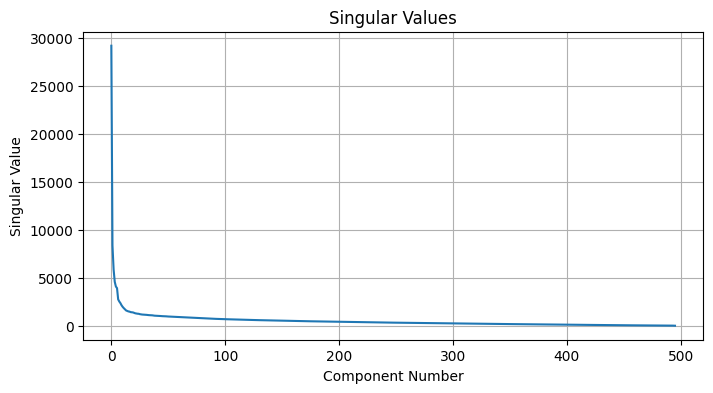

k для 95% информации: 77
k для 98% информации: 163


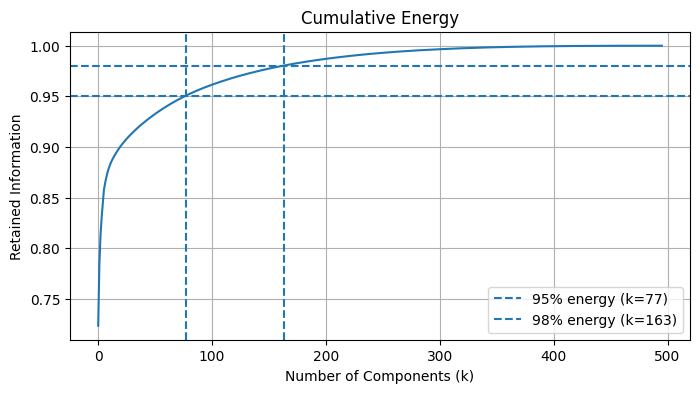

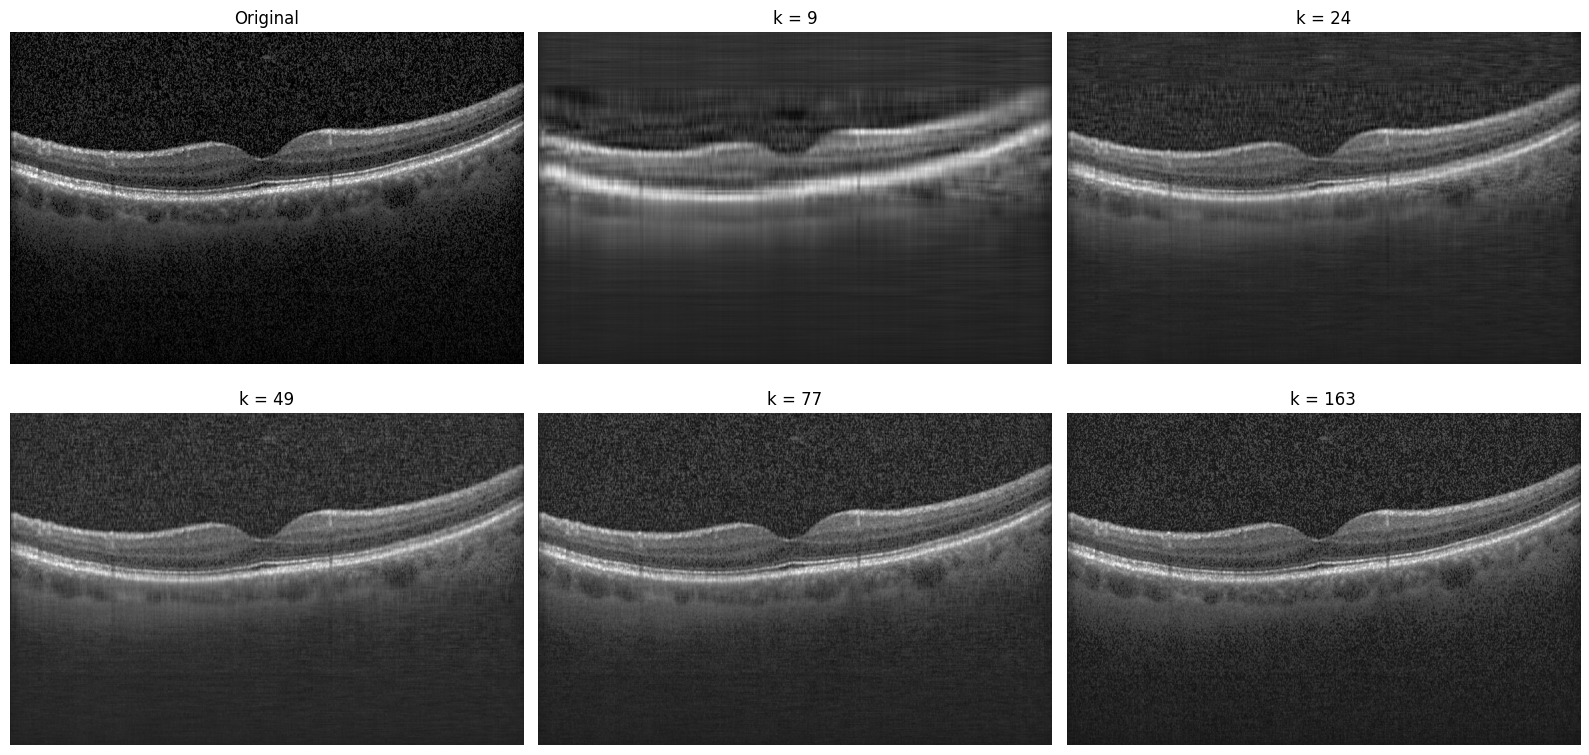

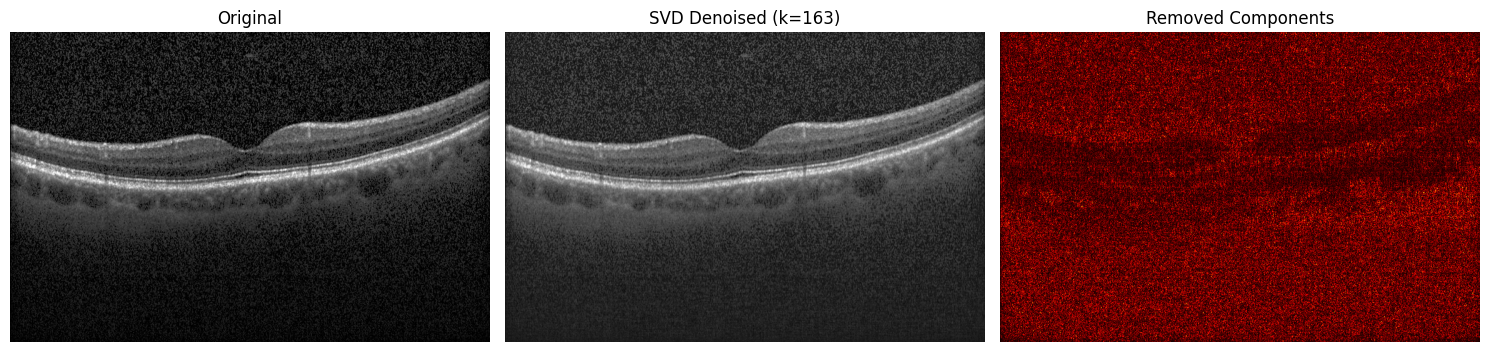

Файл сохранён: oct_denoised.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Загрузка изображения

img = cv2.imread("NORMAL-1025847-1.jpeg", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Изображение не найдено")

print("Размер изображения:", img.shape)

# SVD-разложение

U, S, VT = np.linalg.svd(img, full_matrices=False)

max_rank = len(S)

print("Максимальное количество компонент:", max_rank)

# График сингулярных значений

plt.figure(figsize=(8,4))
plt.plot(S)
plt.title("Singular Values")
plt.xlabel("Component Number")
plt.ylabel("Singular Value")
plt.grid(True)
plt.show()

# Накопленная энергия

energy = np.cumsum(S**2) / np.sum(S**2)

k95 = np.argmax(energy >= 0.95) + 1
k98 = np.argmax(energy >= 0.98) + 1

print(f"k для 95% информации: {k95}")
print(f"k для 98% информации: {k98}")

plt.figure(figsize=(8,4))

plt.plot(energy)

plt.axhline(y=0.95,linestyle='--',label=f'95% energy (k={k95})')

plt.axhline(y=0.98,linestyle='--',label=f'98% energy (k={k98})')

plt.axvline(x=k95,linestyle='--')

plt.axvline(x=k98,linestyle='--')

plt.title("Cumulative Energy")
plt.xlabel("Number of Components (k)")
plt.ylabel("Retained Information")
plt.legend()
plt.grid(True)
plt.show()

# Визуализация разных k

k_values = [
    max(1, int(max_rank * 0.02)),
    max(1, int(max_rank * 0.05)),
    max(1, int(max_rank * 0.10)),
    k95,
    k98]

plt.figure(figsize=(16,8))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

for i, k in enumerate(k_values):

    img_svd = (U[:, :k]@ np.diag(S[:k])@ VT[:k, :])

    plt.subplot(2,3,i+2)
    plt.imshow(img_svd, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Автоматический денойзинг

k = k98

img_denoised = (U[:, :k]@ np.diag(S[:k])@ VT[:k, :])

# Удалённые компоненты

noise_removed = np.abs(
    img.astype(np.float32)
    - img_denoised.astype(np.float32))

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(img_denoised, cmap='gray')
plt.title(f"SVD Denoised (k={k})")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(noise_removed, cmap='hot')
plt.title("Removed Components")
plt.axis('off')

plt.tight_layout()
plt.show()

# Сохранение результата

img_denoised = np.clip(img_denoised, 0, 255).astype(np.uint8)

cv2.imwrite("oct_denoised.png",img_denoised)

print("Файл сохранён: oct_denoised.png")